In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset

from glob import glob
from scipy.io import wavfile
from IPython.display import Audio, display

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [4]:
DATA_DIR = "Final Project Data/genres_original"
file_paths = glob(os.path.join(DATA_DIR, "*", "*.wav"))

rows =[]
for path in file_paths:
    if(path != "Final Project Data/genres_original/jazz/jazz.00054.wav"):
        genre = path[path.rfind("/") + 1 : path.find(".")]
        song_id = path[path.rfind("/") + 1 :].replace(".wav", "")
        rows.append({"path": path, "genre": genre, "song_id": song_id})
df = pd.DataFrame(rows).sort_values(["genre", "song_id"]).reset_index(drop=True)
df

,path,genre,song_id
0,Final Project Data/genres_original/blues/blues...,blues,blues.00000
1,Final Project Data/genres_original/blues/blues...,blues,blues.00001
2,Final Project Data/genres_original/blues/blues...,blues,blues.00002
3,Final Project Data/genres_original/blues/blues...,blues,blues.00003
4,Final Project Data/genres_original/blues/blues...,blues,blues.00004
...,...,...,...
994,Final Project Data/genres_original/rock/rock.0...,rock,rock.00095
995,Final Project Data/genres_original/rock/rock.0...,rock,rock.00096
996,Final Project Data/genres_original/rock/rock.0...,rock,rock.00097
997,Final Project Data/genres_original/rock/rock.0...,rock,rock.00098


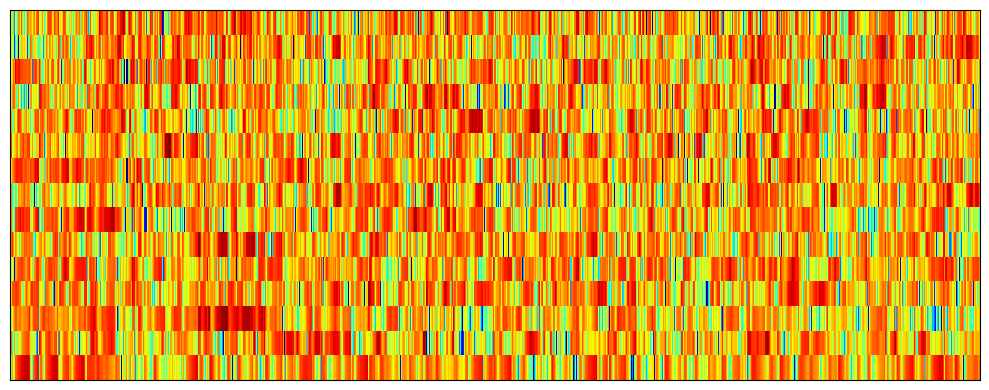

In [5]:
path = df.loc[1, "path"]
y, sr = librosa.load(path, sr=22050, mono=True)

n_mfcc = 15
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
mfcc_db = librosa.power_to_db(mfcc**2, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mfcc_db,
    sr=sr,
    hop_length=512,
    cmap="jet",     
    vmin=-60,        
    vmax=0,
    y_axis=None               
)
plt.tight_layout()
plt.show()

In [6]:
def create_mfcc_spectrogram(y, sr, out_path):
    n_mfcc = 15
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
    mfcc_db = librosa.power_to_db(mfcc**2, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mfcc_db,
        sr=sr,
        hop_length=512,
        cmap="jet",     
        vmin=-60,        
        vmax=0,
        y_axis=None               
    )
    
    plt.axis("off")
    plt.tight_layout(pad=0)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close()

In [7]:
le = LabelEncoder()
y = le.fit_transform(df["genre"].values)

X = []
for path, genre in zip(df["path"].values, df["genre"].values):
    y_audio, sr = librosa.load(path, sr=22050, mono=True)
    number = path[path.rfind("0") + 1 :]
    out_path = os.path.join("mfcc_spectograms", genre, f"{number}.png")
    create_mfcc_spectrogram(y_audio, sr, out_path)
    X.append(out_path)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
import cv2
from torchvision import transforms
from PIL import Image
IMG_SIZE = 128 

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

# no augmentation for test data
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

def load_images(paths, transform):
    X = []
    for p in paths:
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR → RGB
        img = Image.fromarray(img)                  # convert to PIL
        img = transform(img)                        # apply transforms
        X.append(img)

    X = torch.stack(X)
    return X

X_train_tensor = load_images(X_train, train_transform).to(DEVICE)
X_test_tensor  = load_images(X_test, test_transform).to(DEVICE)

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

In [9]:
# =========================
# 6) 2D CNN Classifier
# =========================
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
# =========================
# 7) Initialize model
# =========================
num_classes = 10

model = CNNClassifier(
    num_classes=num_classes,
    dropout_p=0.3
).to(DEVICE)

In [11]:
# =========================
# 7) Training loop
# =========================

def train(model, X, y, epochs=50, lr=1e-3, weight_decay=1e-4):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        opt.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()

        if epoch in [1, 25, 50, 75, 100]:
            print(f"Epoch {epoch:3d} | train loss: {loss.item():.6f}")

train(model, X_train_tensor, y_train_tensor, epochs=30)

Epoch   1 | train loss: 2.303318
Epoch  25 | train loss: 1.608972


In [28]:
# =========================
# 9) Evaluation
# =========================
def weighted_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return acc, prec, rec, f1

model.eval()
with torch.no_grad():
    yhat_tr = model(X_train_tensor).argmax(dim=1).cpu().numpy()
    yhat_te = model(X_test_tensor).argmax(dim=1).cpu().numpy()

tr = weighted_metrics(y_train, yhat_tr)
te = weighted_metrics(y_test, yhat_te)

out = pd.DataFrame(
    [["2D CNN", *tr, *te]],
    columns=[
        "Model",
        "Train Acc","Train Prec(w)","Train Rec(w)","Train F1(w)",
        "Test Acc","Test Prec(w)","Test Rec(w)","Test F1(w)"
    ]
)

print("\n=== 2D CNN Results ===")
print(out.to_string(index=False, formatters={c:"{:.4f}".format for c in out.columns if c!="Model"}))


=== 2D CNN Results ===
 Model Train Acc Train Prec(w) Train Rec(w) Train F1(w) Test Acc Test Prec(w) Test Rec(w) Test F1(w)
2D CNN    0.1001        0.0100       0.1001      0.0182   0.1000       0.0100      0.1000     0.0182


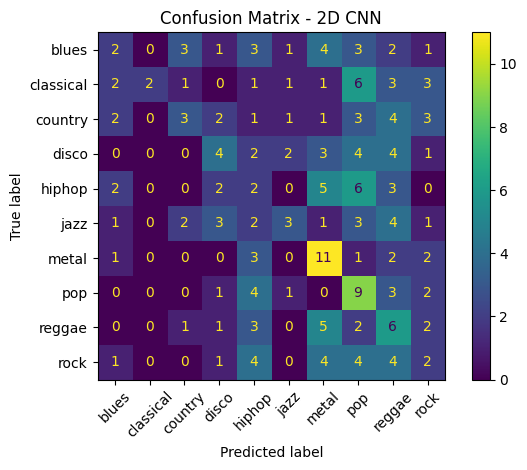

In [13]:
cm = confusion_matrix(y_test, yhat_te)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - 2D CNN")
plt.tight_layout()
plt.show()

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 32
epochs = 40
lr = 1e-3
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

num_classes = len(le.classes_)

In [30]:
full_train_ds = TensorDataset(X_train_tensor.cpu(), y_train_tensor.cpu())

val_size = int(0.2 * len(full_train_ds))
train_size = len(full_train_ds) - val_size

train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

test_ds = TensorDataset(X_test_tensor.cpu(), y_test_tensor.cpu())

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [36]:
class CNN2D_MFCC(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # input: (3,128,128)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (16,64,64)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (32,32,32)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)                               # (64,16,16)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN2D_MFCC(n_classes=num_classes).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [37]:
best_val_loss = float("inf")
best_state = None

for ep in range(1, epochs + 1):
    model.train()
    train_loss_sum, train_n, train_correct = 0.0, 0, 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = loss_fn(logits, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss_sum += loss.item() * yb.size(0)
        train_n += yb.size(0)
        train_correct += (logits.argmax(1) == yb).sum().item()

    model.eval()
    val_loss_sum, val_n, val_correct = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = loss_fn(logits, yb)

            val_loss_sum += loss.item() * yb.size(0)
            val_n += yb.size(0)
            val_correct += (logits.argmax(1) == yb).sum().item()

    train_loss = train_loss_sum / train_n
    train_acc = train_correct / train_n
    val_loss = val_loss_sum / val_n
    val_acc = val_correct / val_n

    print(f"Epoch {ep:02d}/{epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()

# load best model
model.load_state_dict(best_state)

Epoch 01/40 | train_loss=2.3438 | train_acc=0.0984 | val_loss=2.3016 | val_acc=0.1195
Epoch 02/40 | train_loss=2.3048 | train_acc=0.0828 | val_loss=2.3056 | val_acc=0.1132
Epoch 03/40 | train_loss=2.3035 | train_acc=0.0922 | val_loss=2.3033 | val_acc=0.1195
Epoch 04/40 | train_loss=2.3035 | train_acc=0.1016 | val_loss=2.3033 | val_acc=0.1384
Epoch 05/40 | train_loss=2.2776 | train_acc=0.1297 | val_loss=2.2879 | val_acc=0.1572
Epoch 06/40 | train_loss=2.2243 | train_acc=0.1766 | val_loss=2.2112 | val_acc=0.1572
Epoch 07/40 | train_loss=2.1044 | train_acc=0.2031 | val_loss=2.1705 | val_acc=0.2013
Epoch 08/40 | train_loss=1.9569 | train_acc=0.2828 | val_loss=2.1277 | val_acc=0.2013
Epoch 09/40 | train_loss=1.8625 | train_acc=0.3078 | val_loss=2.1454 | val_acc=0.1761
Epoch 10/40 | train_loss=1.6906 | train_acc=0.3703 | val_loss=2.3244 | val_acc=0.2075
Epoch 11/40 | train_loss=1.5251 | train_acc=0.4531 | val_loss=2.4876 | val_acc=0.2138
Epoch 12/40 | train_loss=1.2909 | train_acc=0.5531 | v

<All keys matched successfully>


=== TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       blues     0.1176    0.1000    0.1081        20
   classical     0.3214    0.4500    0.3750        20
     country     0.2778    0.2500    0.2632        20
       disco     0.3125    0.2500    0.2778        20
      hiphop     0.2857    0.1000    0.1481        20
        jazz     0.1538    0.4000    0.2222        20
       metal     0.5333    0.4000    0.4571        20
         pop     0.2857    0.2000    0.2353        20
      reggae     0.4000    0.3000    0.3429        20
        rock     0.1667    0.1500    0.1579        20

    accuracy                         0.2600       200
   macro avg     0.2855    0.2600    0.2588       200
weighted avg     0.2855    0.2600    0.2588       200



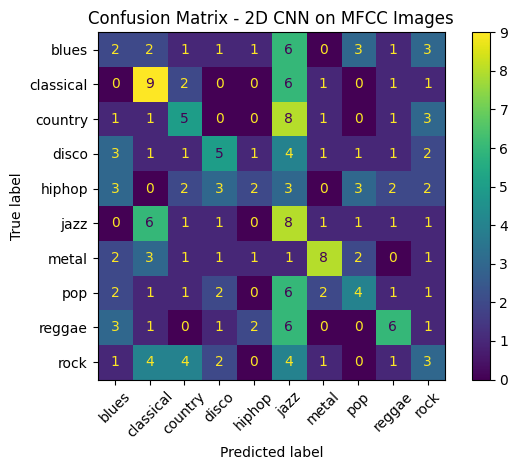

In [38]:
# -------------------------------
# 4) Predict helper
# -------------------------------
@torch.no_grad()
def predict(loader):
    model.eval()
    ys, yh = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = logits.argmax(1).cpu().numpy()

        yh.append(pred)
        ys.append(yb.numpy())

    return np.concatenate(ys), np.concatenate(yh)

y_true, y_hat = predict(test_loader)

print("\n=== TEST CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_hat, target_names=le.classes_, digits=4))

cm = confusion_matrix(y_true, y_hat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - 2D CNN on MFCC Images")
plt.tight_layout()
plt.show()